# Capítulo 4: Problemas a valores iniciales

>[4.1. Introducción](#sec:introduccion)
>
>[4.2. Existencia y estabilidad de soluciones](#sec:existencia.y.estabilidad)
>
>[4.3. Método de Euler](#sec:metodo.de.euler)
>
>[4.4. PVI para sistemas de ecuaciones y ecuaciones de orden superior](#sec:PVI.para.sistemas)
>
>[4.5. Métodos de Runge-Kutta](#sec:metodos.de.RK)
>
>[4.6. Cómo calcular soluciones con una precisión deseada](#sec:como.calcular.soluciones)
>
>[4.7. Estabilidad de métodos numéricos](#sec:estabilidad.de.métodos.numéricos)

## 4.1. Introducción <a name = "sec:introduccion" ></a>

El objetivo en un problema a valores iniciales (PVI) es encontrar una función $y(t)$ dado su valor en un instante inicial $t=T_0$ y una receta $f(t,y)$ para su pendiente se satidfaga que:

$$
\text{(PVI)} \left\{
  \begin{aligned} y' &= f(t,y), \qquad  t \in (T_0,T_f), \\
    y(T_0) &= y_0.
  \end{aligned}
\right.
$$

En algunas aplicaciones se desea graficar una aproximación a $y(t)$ sobre un intervalo de interés $[T_0 ,T_f ]$ para descubrir propiedades cualitativas de la solución (máximos y mínimos, periodicidad, etc.). En otras, puede ser importante conocer una estimación precisa del valor $y(t)$ para un tiempo $t$ prefijado.

Los datos conocidos de (PVI) son: el *valor inicial* $y_0$ y la *función pendiente* $f(t,y)$ que nos dice cuál tiene que ser la pendiente de la solución $y(t)$ en cada instante de tiempo, dependiendo de cuanto vale $y$. Más precisamente:

Se llama *solución de* (PVI) a una función $y(t)$ definida sobre el intervalo $[T_0 ,T_f ]$ que satisface:

$$
y(T_0 ) = y_0, \qquad y'(t) = f(t, y(t)), \quad \text{para todo $t \in (T_0 ,T_f)$.}
$$

> ### Observación
> Existen muchos detalles técnicos en los cuales no nos adentraremos sobre cómo definir apropiadamente el problema y la regularidad de la solución. Quienes tengan interés pueden buscar más información en bibliografía clásica sobre EDOs.
> A los fines prácticos de este curso nuestra función $y$ siempre será lo suficientemente suave para que el problema esté bien definido, haya solución y los métodos numéricos basados en aproximaciones polinómicas que veremos en este curso convergerán correctamente.

### **Ejemplo 1** <a name = "ejem:1"></a>

Consideremos por ejemplo el PVI

$$
\left\{ \begin{aligned} y' &=  -2 y, \quad 0 \le t < \infty, \\
y(0) &= 3.
\end{aligned}
\right.
$$

En este caso, el valor inicial es $3$ y la función pendiente es $f(t,y) = -2y$ (es una función de dos variables que en realidad depende de una sola).
La ecuación diferencial $y' = -2 y$ tiene una *familia* de soluciones, son todas las funciones de la forma $y(t) = c e^{-2t}$, con $c$ cualquier constante. La condición inicial $y(0) = 3$ nos dice que queremos hallar la única función de esa familia que en $t=0$ vale 3. Utilizamos la condición inicial para despejar $c$ y nos da que $c=3$. Luego, la solución del PVI es $y(t) = 3 e^{-2t}$.

## 4.2. Existencia y estabilidad de soluciones <a name = "sec:existencia.y.estabilidad" ></a>

Vimos un ejemplo muy sencillo donde hallar la solución fue muy fácil. En general, esto no es tan fácil, como tampoco es obvio que haya solución del problema. A continuación enunciamos una propiedad que nos afirma la existencia de una solución para (PVI).

Si $f$ es una función continua de sus dos variables ($y$ y $t$) y además $\frac{\partial f}{\partial y}$ existe y está acotada, entonces el problema a valores iniciales (PVI) tiene una única solución.

Más aún, si $L \le \frac{\partial f}{\partial y} \le U$ para todo $(y,t)$, resulta lo siguiente:

Si $y$, $\tilde y$ son soluciones de $y' = f(t,y)$ con $y(T_0 )=y_0$ y $\tilde y(T_0 ) = \tilde y_0$, entonces,

$$
|y_0 - \tilde y_0| e^{L(t-T_0 )} \le | y(t) - \tilde y(t) | \le |y_0 - \tilde y_0| e^{U(t-T_0 )}, \qquad \text{para }t \in [T_0  , T_f ].
$$

En palabras, el resultado anterior nos dice que las soluciones del mismo problema, con diferentes condiciones iniciales, *se alejan* al menos tan rápido como $e^{Lt}$ y no más rápido que $e^{Ut}$ por la diferencia entre las condiciones iniciales.

En el [Ejemplo 1](#ejem:1), $f(t,y) = -2y$, luego $\frac{\partial f}{\partial y} = -2$, y por lo tanto $L=U=-2$. En este caso, tenemos que soluciones del mismo PVI con dos condiciones iniciales diferentes se acercan como $e^{-2t}$ por el *error inicial*. Más precisamente, observemos las soluciones con $y_0 = 3$ y con $\tilde y_0 = 3.1$. En este caso,

$$
y(t) = 3 e^{-2t}, \quad\text{y} \quad \tilde y(t) = 3.1 e^{-2t},
$$

por lo que

$$
|y(t) - \tilde y(t)| = |3 e^{-2t} - 3.1 e^{-2t}| = |3 - 3.1| e^{-2t} = 0.1 e^{-2t}.
$$

> #### Importante
> Si estamos en un caso en que $\frac{\partial f}{\partial y}\le 0$ entonces $U=0$ y tenemos que
>
> $$|y(t)-\tilde y(t)| \le | y_0 - \tilde y_0 |,  \qquad \text{para }t \in [T_0  , T_f ].$$
>
> Es decir, las soluciones *no se alejan*.

## 4.3. Método de Euler <a name = "sec:metodo.de.euler" ></a>

Los métodos que desarrollaremos en el curso producen una sucesión de instantes de tiempo $t_1$, $t_2$, $\dots$, y valores aproximados $Y_1$, $Y_2$, $\dots$, que se espera sean aproximados a $y(t_1)$, $y(t_2)$, $\dots$.

Todo lo que tenemos a disposición es la *función pendiente* $f(t,y)$, que puede evaluarse cuando sea necesario.

Recordando que la definición de derivada es

$$
y'(t) = \lim_{h \to 0} \frac{y(t+h) - y(t)}h,
$$

resulta, para $h>0$ pequeño,

$$
\frac{y(t+h) - y(t)}h \approx y'(t).
$$

Si $y$ es solución de (PVI) entonces, para un parámetro $h>0$ pequeño,

$$
 \frac{y(t+h) - y(t)}h \approx y'(t) = f(t,y(t)),
$$

es decir

$$
y(t+h) \approx y(t) + h f(t,y(t)).
$$

En palabras, conocido (o aproximado) el valor de $y(t)$, el valor de $y(t+h)$ es aproximadamente $y(t) + h f(t,y(t))$.

El **método de Euler** se basa en esta idea y consiste en lo siguiente:

* Particionar el intervalo $[T_0,T_f]$ en $L$ subintervalos de longitud $h = (T_f-T_0)/L$.
* Definir $t_i = T_0 + i\,h$, para $i=0,2,\dots L$.
* Definir $Y_0 = y_0$ ($Y_0 = y(t_0) = y({T_0})$).
* Para $i=0,2,\dots,L-1$, definir $Y_{i+1} = Y_i + h f(t_i, Y_i)$.

Es decir:
$$
\begin{align*}
t_0 &= T_0 & & Y_0=y_0 \\
t_1 &= T_0 + h & & Y_1=Y_0 + h \, f(t_0,Y_0) \\
t_2 &= T_0 + 2h & & Y_2=Y_1 + h \, f(t_1,Y_1) \\
t_3 &= T_0 + 3h & & Y_3=Y_2 + h \, f(t_2,Y_2) \\
&\vdots & &\quad \vdots \\
t_{L} &= T_0 + Lh = T_f & & Y_{L}=Y_{L-1} + h \, f(t_{L-1},Y_{L-1}) \\
\end{align*}
$$

De esta manera se obtienen $L+1$ números $Y_0$, $Y_1$, $Y_2$,$\dots$,$Y_{L}$ que se espera aproximen a $y(t_0)$, $y(t_1)$, $y(t_2)$,$\dots$,$y(t_{L})$.

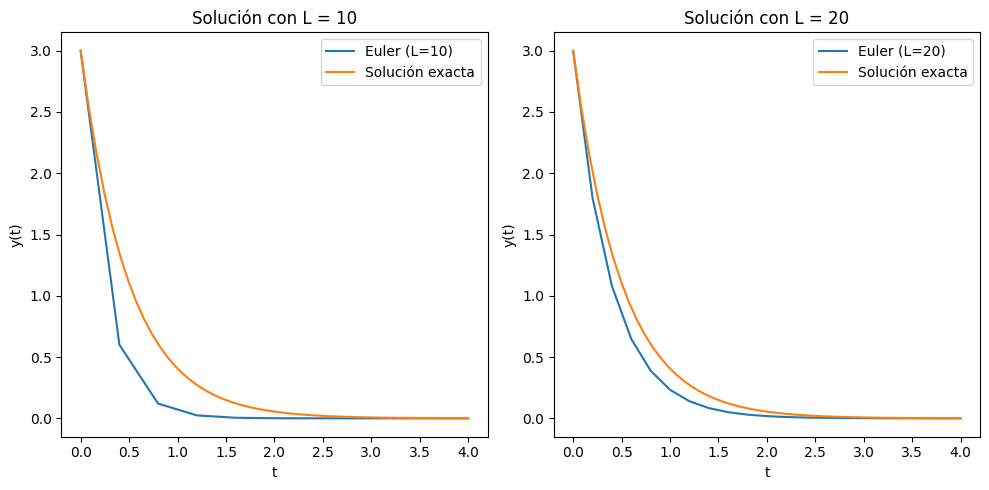

In [ ]:
# @title Solución por el método de Euler a distintos L
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt

f = lambda t, y: -2*y
#Definimos el intervalo
inter = [0, 4]
#Cantidad de divisiones
L1 = 10
L2 = 20

y0 = 3

t1 = np.linspace(inter[0], inter[1], L1 + 1)
h1 = (inter[1] - inter[0]) / L1
t2 = np.linspace(inter[0], inter[1], L2 + 1)
h2 = (inter[1] - inter[0]) / L2

y1 = np.zeros(L1 + 1)
y2 = np.zeros(L2 + 1)

y1[0], y2[0] = y0, y0

#implementamos el método
for n in range(L1):
  y1[n + 1] = y1[n] + h1 * f(t1[n], y1[n])
for n in range(L2):
  y2[n + 1] = y2[n] + h2 * f(t2[n], y2[n])

# Definimos la solución exacta
y_exacta = lambda t: 3 * np.exp(-2 * t)

# Graficamos las soluciones en dos gráficos distintos, uno al lado del otro
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Gráfico 1: Solución con L = 20
t_fina = np.linspace(inter[0], inter[1])
ax1.plot(t1, y1, label='Euler (L=10)')
ax1.plot(t_fina, y_exacta(t_fina), label='Solución exacta')
ax1.set_title('Solución con L = 10')
ax1.set_xlabel('t')
ax1.set_ylabel('y(t)')
ax1.legend()

# Gráfico 2: Solución con L = 40
ax2.plot(t2, y2, label='Euler (L=20)')
ax2.plot(t_fina, y_exacta(t_fina), label='Solución exacta')
ax2.set_title('Solución con L = 20')
ax2.set_xlabel('t')
ax2.set_ylabel('y(t)')
ax2.legend()

# Ajustar el espaciado entre los gráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()


En las gráficas podemos observar la solución obtenida y la exacta para el ejemplo que venimos trabajando, con $L=10$ y $L=20$ sobre el intervalo $[0,4]$. Vemos en particular como al duplicar la cantidad de intervalos, la solución obtenida se aproxima más a la exacta.

A continuación se define la función `euler1` que tiene una implementación del
método de Euler.


In [ ]:
def euler1(f, inter, y0, L):
  """
  Método de Euler para resolver
  y’ = f(t,y) en (t0,tf)
  y(t0) = y0
  Usando L pasos
  """
  t = np.linspace(inter[0], inter[1], L + 1)
  h = (inter[1] - inter[0]) / L
  # reservamos lugar en memoria para y
  y = np.zeros(L + 1)
  y[0] = y0
  for n in range(L):
    y[n + 1] = y[n] + h * f(t[n], y[n])
  return t, y

### Cómputo del error

Es claro que en cada paso se comete un error, pequeño si $h$ es pequeño, pero estos errores de alguna manera se *acumulan*, y para llegar a $T_f $ la cantidad de pasos será mayor cuanto menor sea $h$.

Para entender un poco mejor el error cometido, necesitamos definir algunas cantidades:

**Error global:** Se llama error global al máximo error entre $y(t_n)$ y $Y_n$, es decir,

$$
g_n = | y(t_n) - Y_n|, \qquad \text{error global} = \max\limits_{0\le n \le L} g_n = \max\limits_{0\le n \le L} |y(t_n)-Y_n|.
$$

**Error local de truncamiento:**
Llamamos $y_j$ a las soluciones de $y'= f(t,y)$ que pasan por $(t_j,Y_j)$, más precisamente, comienzan en $t_j$ y cumplen la condición inicial $y_j(t_j) = Y_j$, es decir,

$$
\left\{
  \begin{aligned} y_j' &= f(t,y_j), \qquad t_j \le t \le t_f , \\
    y_{j}(t_j) &= Y_j.
  \end{aligned}
\right.
$$

Notemos que con esta definición, $y(t) = y_0(t)$. Definimos entonces

$$
\text{error local de truncamiento} = \varepsilon_j = |y_j(t_{j+1}) - Y_{j+1}|,
$$

es decir, el error local de truncamiento $\varepsilon_j$ es el error que se comete en el paso $j$, suponiendo que no había error acumulado. Notar que el error global es $g_j = |y_0(t_j) - Y_j|$ (siempre compara con $y(t) = y_0(t)$).

Ahora sí estamos en condiciones de hacer el análisis del error global. Para fijar ideas, supongamos que $\frac{\partial f}{\partial y} \le 0$ de manera que las *trayectorias no se alejan*, más precisamente, si $t \ge t_{j+1}$,

$$
| y_j(t) - y_{j+1}(t) | \le |y_j(t_{j+1}) - y_{j+1}(t_{j+1})|
= |y_j(t_{j+1}) - Y_{j+1}| = \varepsilon_j.
$$

Entonces

$$
\begin{align*}
g_n &= |Y_n - y(t_n)| = |Y_n - y_0(t_n)| \\
    &\le |Y_n - y_{n-1}(t_n)| + |y_{n-1}(t_n) - y_{n-2}(t_n)| + \dots + |y_1(t_n) - y_0(t_n)| \\
    &\le \varepsilon_{n-1} + \varepsilon_{n-2} + \dots + \varepsilon_0 = \sum_{j=0}^{n-1} \varepsilon_j.
\end{align*}
$$

Por lo tanto, el máximo error global puede acotarse por

$$
\begin{equation}
\max\limits_{0\le n \le L} g_n \le \max\limits_{0\le n \le L} \sum_{j=0}^{n-1} \varepsilon_j
= \sum_{j=1}^{L} \varepsilon_j
\le L \max\limits_{1\le j \le L} \varepsilon_j.
\end{equation} \qquad (4.1)
$$

Hasta aquí , el análisis que hemos hecho es independiente del método, si es Euler o algún otro. Veamos cómo se puede acotar $\varepsilon_j$ para el método de Euler.

Una herramienta muy utilizada para estimar y acotar el error en los métodos numéricos es el Teorema de Taylor, que enunciamos a continuación:

> <font size="5">Teorema 4.1. (Teorema de Taylor)</font> <a name = "teo:PVI.para.sistemas.v1"></a>
>
> Sea $y \in C^{n+1}(I)$, donde $I$ es un intervalo que contiene a $t_0$. Entonces, para cada $t \in I$ existe $x$ entre $t_0$ y $t$ tal que
>
> $$
y(t) = y(t_0) + (t-t_0) y'(t_0) + \frac{(t-t_0)^2}{2!} y''(t_0) + \dots +
  \frac{(t-t_0)^n}{n!} y^{(n)}(t_0) + \frac{(t-t_0)^{n+1}}{(n+1)!} y^{(n+1)}(x).
$$

Usando el teorema de Taylor y considerando que $h = \frac{T_f-T_0}L$ y que $t_{j+1} = t_j+h$, tenemos que

$$
y_j(t_{j+1}) = y_j(t_j) + h y_j'(t_j) + \frac{h^2}2 y_j''(\xi_j)
=\underbrace{ Y_j + h f(t_j,Y_j) }_{Y_{j+1}} + \frac{h^2}2 y_j''(x_j)
$$

para algún $x_j$, con $t_j < x_j < t_{j+1}$. Por lo tanto,

$$
\varepsilon_j = | y_j(t_{j+1}) - Y_{j+1} | = | y_j(t_{j+1}) -
[ Y_j + h f(t_j,Y_j)] | = \frac{h^2}2 |y_j''(x_j)|
$$

y si existe $M>0$ tal que $\max\limits_{T_0\le t \le T_f} |y_j''(t)| \le M$, $j=1,\dots,L$, entonces

$$
\varepsilon_j \le \frac{M h^2}2, \quad j=1,2,\dots,L.
$$

Finalmente, acotamos el error global usando (4.1):

$$
\max\limits_{1\le n \le L} |Y_n - y(t_n)| \le L \max\limits_{1\le j \le L} \varepsilon_j
\le L \frac{M h^2}2 = \underbrace{Lh}_{T_f-T_0} \frac{Mh}2 = \frac{M (T_f-T_0)}2 h .
$$


Concluimos entonces que si todas las soluciones de la EDO tienen derivada segunda acotada uniformemente por $M$, el método de Euler produce una solución con máximo error acotado por $\frac{M (T_f-T_0)}2 h = \text{Const.} \times h$. Se dice que el método de Euler es de orden uno (la potencia de $h$).
La demostración que hemos visto es muy simple, y analizando el caso $\frac{\partial f}{\partial y} \le 0$, permite entender la idea general que si un método produce en un paso un error de orden $h^{k+1}$ entonces el error global será de orden $h^k$.

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Euler 1</font>

Considere el método de Euler para resolver el siguiente PVI:

$$
\text{} \left\{
  \begin{aligned} y' &= -y, \qquad 0  \le t \le 1  , \\
    y(0 ) &= 1.
  \end{aligned}
\right.
$$



1.   Obtenga el valor $y(1)$ con una precisión de 4 dígitos decimales. (Si se empieza con $L = 10$, indique cuántas duplicaciones de $L$ son necesarias para llegar a la precisión deseada).

2.   ¿Cuánto vale $y(t)$ para $t = 0.687$? De su resultado con 3 decimales exactos.

3. Sabiendo que este PVI tiene solución exacta $y(t) = e^{−t}$, complete la siguiente tabla:

|L|h| $E_L$ | $\frac{E_{L/2}}{E_L}$ |
|-|-|-|-|
|10|0.1| | |
|20|0.05| | |
|40|0.025| | |
|80|0.0125| | |
|160|0.00625| | |
|320|0.003125| | |
|640|0.0015625| | |
|1280|0.00078125| | |

Aquí, el error global con $L$ pasos es $E_L = \max\limits_{1≤i≤L+1}|y(t_i)-Y_i|$. Si el método está bien implementado, debería ocurrir que el error global se divide aproximadamente a la mitad cuando se duplica la cantidad de pasos.

*Sugerencia: para armar una tabla a partir de vectores, explore la función ```DataFrame``` de la librería ```pandas```.*



In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Euler 2</font>

Considere el PVI

$$
\text{} \left\{
  \begin{aligned} y' &= f(t,y) = -\cos(2\pi t^2) - t y , \qquad 0  \le t \le 4  , \\
    y(0 ) &= 2.
  \end{aligned}
\right.
$$

1.   Resuelva con el método de Euler. Utilice diferentes valores de $L$ (por ejemplo: 10, 20, 40, 80, 160, . . . ) y grafique las aproximaciones de la solución que se van obteniendo. Determine un valor de $L$ para el que la
aproximación obtenida visualmente coincide con la solución del problema.

2.   Calcule el máximo y el mínimo de la solución del PVI en el intervalo $[0, 4]$. Obtenga los valores de $t$ donde éstos se alcanzan.

3. Encuentre el valor aproximado de $t$ para el cual $y(t) = 1$.

4. Calcule ahora las tres soluciones de la misma ecuación diferencial pero con condición inicial $y(0) = 1$, $y(0) = 0$ y $y(0) = -1$, respectivamente. Grafíquelas todas sobre el mismo par de ejes y diga que ocurre a medida que el tiempo $t$ avanza. ¿Se acercan o se alejan las trayectorias? ¿Cómo se relaciona esto con $\frac{\partial f}{\partial y}$ ?




In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Euler 3</font>

Considere el PVI

$$
\text{} \left\{
  \begin{aligned} y' &= f(t,y) = y(1-y)(1+y) , \qquad 0  \le t \le 2  , \\
    y(0 ) &= y_0.
  \end{aligned}
\right.
$$

1. Utilice el método de Euler con $L = 10000$ pasos para resolver el PVI con $y_0 = -1.4, -1.3, -1.2, . . . , 1.3, 1.4$.
Superponga todas las soluciones en un gráfico y explique el comportamiento cualitativo de las soluciones.

2. Divida el plano $(t, y)$ en zonas donde $\frac{\partial f}{\partial y}$ tenga distinto signo. Utilice estas zonas para justificar, mediante la teoría, lo observado anteriormente.

<font size="4">Ejercicio Euler 4</font>

La radiación y(t) de cierta partícula a tiempo $t$ está gobernada por la ecuación diferencial $y' = 1 - t^2 sen (y)$. La medición del estado inicial (a tiempo $t=0$) indica que $y(0) = 1.57$,

1. Encuentre el estado de la radiación y a tiempo $t = 5$, con error absoluto menor a $10^{-6}$.

2. Encuentre el o los instantes en que la radiación toma el valor $2$.

3. A partir del tiempo $t = 5$, la radiación cambia abruptamente de comportamiento, observándose que la ecuación diferencial que la gobierna ahora es $y' = 1 + y$. ¿Cuanto valdrá la radiación a tiempo $t = 10$?


In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

## 4.4. PVI para sistemas de ecuaciones y ecuaciones de orden superior <a name = "sec:PVI.para.sistemas" ></a>

Consideremos ahora un *sistema* de ecuaciones diferenciales ordinarias. Por ejemplo, un modelo de predador presa:

$$
\begin{equation*}
\left\{
\begin{aligned}
x_1' &= 0.5 x_1 + 0.2 x_1 x_2 \\
x_2' &= 0.8 x_2 - 0.8 x_1 x_2
\end{aligned}
\right.
\qquad
\begin{aligned}
x_1(0) &= 500\\
x_2(0) &= 10000
\end{aligned}
\end{equation*}
$$

Para resolverlo numéricamente, primero lo transformamos en una ecuación diferencial ordinaria *vectorial*. Definimos

$$
x(t) = \begin{bmatrix} x_1(t) \\ x_2(t) \end{bmatrix}
\qquad
x' =  \begin{bmatrix} x_1' \\ x_2' \end{bmatrix} = \begin{bmatrix} 0.5 x_1 + 0.2 x_1 x_2 \\ 0.8 x_2 - 0.8 x_1 x_2 \end{bmatrix}
\qquad
x(0) =  \begin{bmatrix} x_1(0) \\ x_2(0) \end{bmatrix}  =  \begin{bmatrix} 500 \\ 10000 \end{bmatrix}
$$



El PVI entonces resulta:

$$
\left\{\begin{aligned}
x' &= \begin{bmatrix} 0.5 x_1 + 0.2 x_1 x_2 \\ 0.8 x_2 - 0.8 x_1 x_2 \end{bmatrix}
\\
x(0) &=\begin{bmatrix} 500 \\ 10000 \end{bmatrix}
\end{aligned}
\right.
$$

Un PVI para un sistema de ecuaciones diferenciales ordinarias es un problema de la forma:

$$
\begin{equation}
\left\{
\begin{aligned}
y' &= f(t,y) \qquad T_0 \le t \le T_f \\
y(T_0) &= y_0
\end{aligned}
\right.
\end{equation} (4.2)
$$

donde $y_0 \in \mathbb{R}^n$ ($y_0$ es un vector) y $f:[T_0,T_f]\times\mathbb{R}^n \to \mathbb{R}^n$, es decir, $f$ es una función vectorial de dos variables, la primera ($t$) es escalar, y la segunda ($y$) es vectorial.

Con respecto a la existencia y unicidad de soluciones de (4.2), tenemos el siguiente teorema.

> <font size="5">Teorema 4.2.</font> <a name = "teo:PVI.para.sistemas.v2"></a>
>
> Si $f:[T_0,T_f]\times\mathbb{R}^n \to \mathbb{R}^n$ es continua de sus dos variables $(t,y)$ y
$\frac{\partial f_i} {\partial y_j}$ es continua, con $|\frac{\partial f_i}{\partial y_j}| \le M$, entonces el problema (4.2) tiene solución única.



#### **Ejemplo 4.1. (Péndulo ideal)**
Si consideramos un péndulo de brazo rígido de longitud $\ell$,
  donde no hay fricción ni resistencia del aire, el ángulo $\varphi(t)$
  que forma el péndulo con la vertical satisface la siguiente ecuación
  diferencial:

  $$\varphi''(t) = - \frac g\ell \sin \varphi(t)$$

  donde $g$ denota la constante de aceleración gravitacional. Esta es una ecuación diferencial ordinaria de orden dos, pues aparecen derivadas segundas de la incógnita $\varphi$.

  

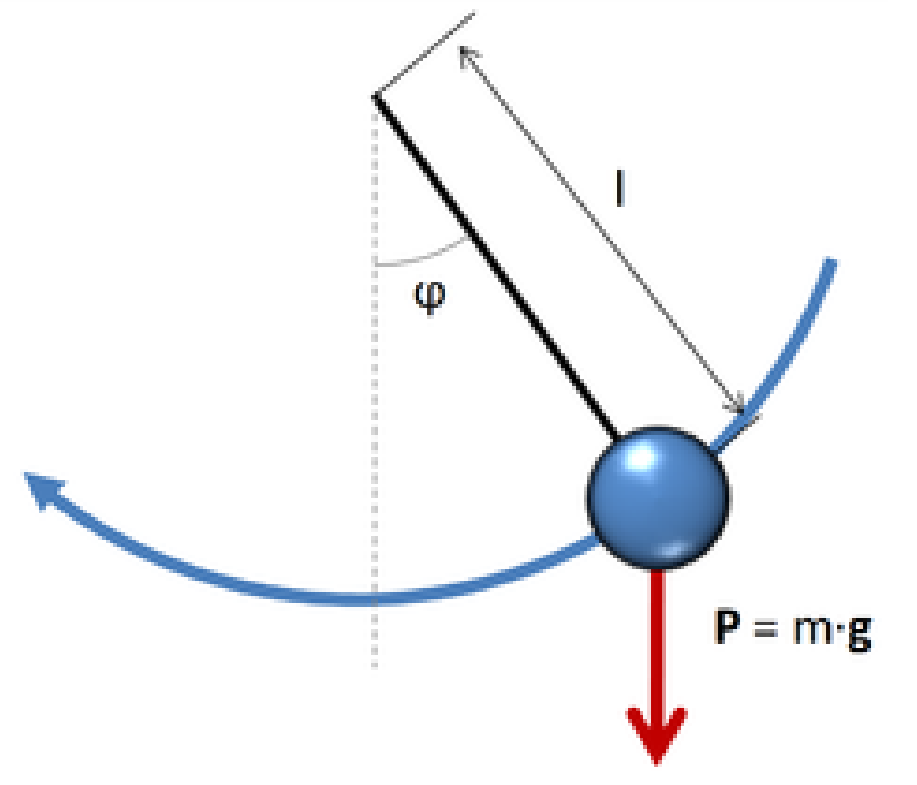

Este problema resulta un PVI cuando se complementa con dos condiciones iniciales:

$$
\varphi(0) = \varphi_0,\qquad
\varphi'(0) = v_0,
$$

donde $\varphi_0$ denota el desplazamiento angular inicial (dato) y $v_0$ la velocidad angular inicial (dato).

Para resolver este PVI en la computadora, primero lo transformamos en un *sistema* de ecuaciones diferenciales de *primer* orden, de la siguiente manera:

Definimos

$$
\begin{align*}
y_1 &= \varphi,
\\
y_2 &= \varphi',
\end{align*}
$$

de manera que

$$
\begin{align*}
y_1' &= \varphi' = y_2
\\
y_2' &= \varphi'' = -\frac g\ell \sin \varphi = -\frac g\ell \sin y_1,
\end{align*}
$$

y

$$
y_1(0) = \varphi(0) = \varphi_0, \qquad y_2(0) = \varphi'(0) = v_0.
$$

Ahora reescribimos las ecuaciones en términos de $y_1$, $y_2$ sin usar $\varphi$, $\varphi'$.

$$
\left\{
\begin{aligned}
y_1' &= y_2
\\
y_2' &= -\frac gL \sin y_1,
\end{aligned}
\right.
\qquad
\left\{
\begin{aligned}
y_1(0) = \varphi_0,\\
y_2(0) = v_0.
\end{aligned}
\right.
$$

Si llamamos $y = \begin{bmatrix}y_1\\y_2\end{bmatrix}$ resulta

$$
y' = \begin{bmatrix} y_2 \\ -\frac gL \sin y_1 \end{bmatrix}
\qquad
y(0) = \begin{bmatrix} \varphi_0 \\ v_0 \end{bmatrix}.
$$

Presentamos a continuación una modificación del código de la función `euler1` que sirve también para resolver PVI para sistemas de ecuaciones diferenciales.
La función está diseñada con el siguiente formato:

$$
\texttt{[t,y] = euler(f, [T0 TF], y0, L)}
$$

$
\textbf{Entradas:}
$

* $\texttt{f=f(t,y)}:$ Es una función que recibe dos argumentos, $\texttt{t}$ es un escalar, $\texttt{y}$ es un vector *columna* de $\texttt{n}$ componentes; y retorna un vector columna de $\texttt{n}$ componentes, siendo $\texttt{n=length(y0)}$. Por ejemplo: $\texttt{f = @(t,y) [-t*y(2) ; t*(y(1)-y(2))]}$;
* $\texttt{[T0 TF]}:$ Es un vector de dos componentes que indican el intervalo donde se desea conocer la solución.
* $\texttt{y0}:$ Es un vector columna que indica el *dato inicial*.
* $\texttt{L}:$ Es un número que indica la cantidad de sub-intervalos en que se divide el intervalo $\texttt{[T0 TF]}$ para resolver por el método de Euler.

$\textbf{Salidas:}$
* $\texttt{t}:$ Debe ser un vector columna de $\texttt{L+1}$ componentes.
* $\texttt{y}:$ Debe ser una matriz de $\texttt{L+1}$ filas y $\texttt{n}$ columnas. La $\texttt{i}$-ésima fila debe contener el estado $\texttt{y}$ a tiempo $\texttt{t(i)}$.


In [ ]:
def euler(f, inter, y0, L):
  """
  Método de Euler para resolver
  y’ = f(t,y) en [t0,TF]
  y(t0) = y0
  Usando L pasos
  y0 puede ser vectorial o escalar
  """
  t = np.linspace(inter[0], inter[1], L + 1)
  h = (inter[1] - inter[0]) / L
  # reservamos lugar en memoria para y
  y = np.zeros((len(y0), L + 1))
  y[:, 0] = y0
  for n in range(L):
    y[:, n + 1] = y[:, n] + h * f(t[n], y[:, n])
  return t, y.T

## 4.5. Métodos de Runge-Kutta <a name = "sec:metodos.de.RK" ></a>

Hemos visto el método de Euler, que resulta de orden uno, y en cada paso realiza una evaluación de la función $f$. Nos preguntamos: ¿Se podrá definir un método que utilizando dos evaluaciones de $f$ en cada paso resulte de orden 2? La respuesta es positiva, veamos cómo puede lograrse.

Proponemos un método como el siguiente:

$$
\left\{
  \begin{aligned}
    k_1 &= h f(t_n,Y_n) \\
    k_2 &= h f(t_n+\alpha h , Y_n + \alpha k_1) \\
    Y_{n+1} &= Y_n + a k_1 + b k_2
  \end{aligned}
\right.
$$

¿Se pueden elegir $\alpha$, $a$, $b$ para que el error local sea $O(h^3)$?

Veamos, sea $y(t)$ la solución del PVI siguiente:

$$
\left\{
  \begin{aligned} y' &= f(t,y), \qquad t_n  \le t \le T_f  , \\
    y(t_n ) &= Y_n.
  \end{aligned}
\right.
$$

El error local de truncamiento es entonces $\varepsilon_n = y(t_{n+1})-Y_{n+1}$.



Por el teorema de Taylor,

$$
y(t_{n+1}) = y(t_n) + h y'(t_n) + \frac{h^2}2 y''(t_n) + \frac{h^3}{3!} y'''(x),
$$

pero

$$
\begin{align*}
y'(t_n) &= f(t_n,y(t_n)) = f(t_n,Y_n) = f^n \\
y''(t_n) &= \frac{d}{dt}y'(t)_{|t=t_n} = \frac{d}{dt} f(t,y(t))_{|t=t_n}
= \left[f_t(t,y(t)) + f_y(t,y(t)) y'(t) \right]_{|t=t_n} \\
&= \left[f_t(t,y(t)) + f_y(t,y(t)) f(t,y(t)) \right]_{|t=t_n}
= f_t^n + f_y^n f^n.
\end{align*}
$$



Luego, como $y(t_n) = Y_n$,

$$
y(t_{n+1}) = Y_n + h f^n + \frac{h^2}2 \left(  f_t^n + f_y^n f^n \right) +  \frac{h^3}{3!} y'''(x).
$$

Por otro lado

$$
Y_{n+1} = Y_n + a k_1 + b k_2
$$

con

$$
\begin{align*}
k_1 &= h f^n \\
k_2 &= h f(t_n + \alpha h, Y_n + \alpha k_1 ) \\
    &= h \left[ f(t_n,Y_n) + \alpha h f_t(t_n,Y_n) + \alpha k_1 f_y(t_n,Y_n) + O(h^2) \right] \\
    &= h f^n + \alpha h^2 f_t^n + \alpha h \underbrace{k_1}_{h f^n} f_y^n + O(h^3) \\
    &= h f^n + \alpha h^2 f_t^n + \alpha h^2 f^n f_y^n + O(h^3).
\end{align*}
$$



Por lo tanto

$$
Y_{n+1} = Y_n + (a+b) h f^n + b \alpha h^2 \left( f_t^n + f^n f_y^n \right) + O(h^3).
$$

De esta manera,

$$
Y_{n+1} - y(t_{n+1}) = Y_n - Y_n + [(a+b)-1] h f^n + \big[ b\alpha( f_t^n + f^n f_y^n ) - \frac12 (f_t^n + f f_y^n )\big] h^2 + O(h^3),
$$

y será $\varepsilon_n = |Y_{n+1} - y(t_{n+1})| = O(h^3)$ si

$$
\begin{align*}
a+b &= 1 \\
%b \alpha &= \frac12 \\
b \alpha &= \frac12
\end{align*}
$$

Elegimos la solución *simétrica*

$$
a = \frac12, \quad b = \frac12, \quad \alpha = 1, %\quad \beta = 1,
$$

y obtenemos el método de $\textbf{Runge-Kuta de orden 2}$:


Dados $t_n$ e $Y_n$, calcular $Y_{n+1}$ a partir de las siguientes fórmulas

$$
(RK2)
\left\{
  \begin{aligned}
    k_1 &= h f(t_n,Y_n) \\
    k_2 &= h f(t_n+ h , Y_n +  k_1) \\
    Y_{n+1} &= Y_n + \frac12 k_1 + \frac12 k_2 \\    
  \end{aligned}
\right.
$$



Para este método vale el siguiente resultado:

> <font size="5">Teorema 4.3.</font> <a name = "teo:Rk2"></a>
>
> Si todas las soluciones tienen derivada de orden tres acotada uniformemente por una constante $M_3$, entonces el método de Runge-Kutta de orden 2 produce una sucesión $(t_n,Y_n)$ que cumple
>
> $
\max\limits_{1 \le n \le L+1} |y(t_n) - Y_n| \le C h^2,
$
>
> donde $h = \frac{T_f-T_0}L$ y $C$ depende de $M_3$ y de la longitud del intervalo $[T_0,T_f]$, es decir $(T_f-T_0)$.


De manera análoga, pero con cuentas más engorrosas puede deducirse el método de $\textbf{Runge-Kutta de orden cuatro}$:

Dados $t_n$ e $Y_n$, calcular $t_{n+1}$ e $Y_{n+1}$ a partir de las siguientes fórmulas:

$$
(RK4)
\left\{
  \begin{aligned}
    k_1 &= h f(t_n,Y_n) \\
    k_2 &= h f(t_n+ \frac h2 , Y_n + \frac {k_1}2) \\
    k_3 &= h f(t_n+ \frac h2 , Y_n + \frac {k_2}2) \\
    k_4 &= h f(t_n+ h , Y_n + k_3) \\
    Y_{n+1} &= Y_n + \frac{ k_1 + 2 k_2 + 2 k_3 + k_4}6
  \end{aligned}
\right.
$$

Cabe aclarar aquí que el método de Runge-Kutta de orden cuatro
convergerá con ese orden cuando las derivadas de hasta orden cinco de
$y$ (y cuatro de $f$) están acotadas. Más precisamente
Para este método vale el siguiente resultado:

> <font size="5">Teorema 4.4.</font> <a name = "teo:Rk4"></a>
>
> Si todas las soluciones tienen derivada de orden cinco acotada uniformemente por una constante $M_5$, entonces el método de Runge-Kutta de orden 2 produce una sucesión $(t_n,Y_n)$ que cumple
>
> $
\max\limits_{1 \le n \le L+1} |y(t_n) - Y_n| \le C h^4,
$
>
> donde $h = \frac{T_f-T_0}L$ y $C$ depende de $M_4$ y de la longitud del intervalo $[T_0,T_f]$, es decir $(T_f-T_0)$.


La pregunta que cabe hacerse es la siguiente: ¿Cuál es la ganancia de usar un método de orden superior si es computacionalmente más costoso en cada paso de tiempo? Para ver la ganancia, consideremos el caso en que las cotas del error de Euler, RK2 y RK4 son $h$, $h^2$ y $h^4$ respectivamente, es decir, $C=1$ en todos los casos. Recordemos que la parte más costosa desde el punto de vista computacional es la evaluación de $f(t,y)$, por lo que interpretamos que Euler, RK2 y RK4 cuestan 1, 2 y 4 "operaciones" por paso de tiempo.


En la siguiente tabla mostramos el costo y el error de cada método para diferentes $L$ pensando en el intervalo $[0,1]$.

|        | Euler           |       | Runge-Kutta 2   |       | Runge-Kutta 4   |       |
|--------|-----------------|-------|-----------------|-------|-----------------|-------|
|  *L*   | costo           | error | costo           | error | costo           | error |
|--------|-----------------|-------|-----------------|-------|-----------------|-------|
| 10     | 10              | 0.1   | 20              | 0.01  | 40              | 0.0001|
| 20     | 20              | 0.05  | 40              | 0.0025| 80              | 0.00000625|
| 40     | 40              | 0.025 | 80              | 0.000625| 160             | 0.00000039|
| 80     | 80              | 0.0125| 160             | 0.000156| 320             | 0.000000024|
| 100    | 100             | 0.01  | 200             | 0.0001| 400             | 0.00000001 = 1x10^-8|
|--------|-----------------|-------|-----------------|-------|-----------------|-------|

Vale la pena observar cuál es el error de cada método correspondiente a un costo de 40 evaluaciones y también al que corresponde a 80 evaluaciones.
¡¡Los métodos de orden superior son mucho más eficientes!!
Claro, cada vez que duplicamos $L$, el error por el método de Euler se reduce a la mitad, en cambio el error por el método RK2 se reduce por 4 y el error por RK4 se reduce por 16.

A continuación se definen las funciones `rk2` y `rk4` en las cuales se implementan los métodos de Runge-Kutta de orden 2 y 4 respectivamente.

In [ ]:
def rk2(f, inter, y0, L):
  """
  Método de Runge Kutta de orden 2 para resolver
  y’ = f(t,y) en [t0,TF]
  y(t0) = y0
  Usando L pasos
  y0 puede ser vectorial o escalar
  """
  t = np.linspace(inter[0], inter[1], L + 1)
  h = (inter[1] - inter[0]) / L
  # reservamos lugar en memoria para y
  y = np.zeros((len(y0), L + 1))
  y[:, 0] = y0
  for n in range(L):
      k1=h*f(t[n], y[:, n])
      k2=h*f(t[n+1], y[:, n]+k1)
      y[:, n + 1] = y[:, n] + 0.5 * (k1+k2)
  return t, y.T

In [ ]:
def rk4(f, inter, y0, L):
  """
  Método de Runge Kutta de orden 4 para resolver
  y’ = f(t,y) en [t0,TF]
  y(t0) = y0
  Usando L pasos
  y0 puede ser vectorial o escalar
  """
  t = np.linspace(inter[0], inter[1], L + 1)
  h = (inter[1] - inter[0]) / L
  # reservamos lugar en memoria para y
  y = np.zeros((len(y0), L + 1))
  y[:, 0] = y0
  for n in range(L):
      k1=h*f(t[n], y[:, n])
      k2=h*f(t[n]+h/2, y[:, n]+k1/2)
      k3=h*f(t[n]+h/2, y[:, n]+k2/2)
      k4=h*f(t[n+1], y[:, n]+k3)
      y[:, n + 1] = y[:, n] + (k1+2*k2+2*k3+k4)/6
  return t, y.T

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Runge-Kutta 1</font>

La trayectoria de una partícula que inicialmente se encuentra en el punto $(-1, 1)$ y se mueve en el plano está dada por la curva $\left(x_1(t), x_2(t)\right)$, donde las funciones $x_1$ y $x_2$ son la solución del siguiente sistema
de ecuaciones diferenciales:

$$
\text{} \left\{
  \begin{aligned} x_1'(t) &= -t x_2(t) , \\
    x_2'(t) &= t x_1(t) - t x_2(t).
  \end{aligned}
\right.
$$

1. Grafique la trayectoria de la partícula durante los primeros 20 segundos.

2. Utilice el método de Runge-Kutta 4 con paso h = 0.1 para determinar la posición de la partícula y su rapidez a los tres segundos.

3. ¿Cuántos dígitos correctos tienen los resultados del item anterior? Explique cómo lo determinó.

4. Recuerde que la longitud de la trayectoria de la partícula durante los $T$ primeros segundos está dada por $\int^T_0 \sqrt{x'_1(t)^2 + x'_2(t)^2} dt$. Calcule la distancia recorrida por la partícula durante los primeros tres segundos. Explique cómo lo hizo.

5. Determine el instante de tiempo a partir del cual la partícula está siempre a una distancia menor a 0.01 del origen de coordenadas.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Runge-Kutta 2</font>

Considere siguiente PVI de orden 3:

$$
\text{} \left\{
  \begin{aligned} y'''+4y''+5y'+2y &= -4 \sin(t)-2 \cos(t) , \\
    y(0) &= 1 ,\\
    y'(0) &= 0,\\
    y''(0) &= -1
  \end{aligned}
\right.
$$

1. Reescriba el problema como un sistema de EDO de primer orden, con sus respectivos valores iniciales.

2. Grafique la solución y obtenga el valor de la variable de estado y en $t = 2.5$, con 6 dígitos exactos.

3. Indique cuántas veces se anula la función $y'(t)$ en el intervalo $[0, 15]$.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Runge-Kutta 3</font>

Una paracaidista de masa $m$ salta desde un helicóptero suspendido a una altura inicial de 45 km4. Supóngase que cae verticalmente con una velocidad inicial cero y que solo actáan sobre ella la fuerza de la gravedad y una fuerza hacia arriba $F_R$ debida a la resistencia del aire (en Newtons, y con el eje coordenado dirigido hacia abajo, de tal manera que la velocidad $v$ es positiva durante su descenso al piso).

Si no se abre el paracaídas, teniendo en cuenta la Ley de Newton $F = ma$, se sabe que la velocidad debe satisfacer:

$$m \frac{dv}{dt} = mg - F_R$$,

donde $g = 9.8 m/s^2$. Suponga que la masa de la paracaidista es de $60 kg$ y que $F_R$ está dada en términos de la velocidad $v$ como

$$F_R = 0.0096(100v + 10v^2 + v^3).$$

1. Determinar el problema a valores iniciales que modela esta situación en donde la única variable de estado sea la velocidad $v$.

2. Determine (con tres dígitos decimales exactos) la velocidad en $m/s$ y la aceleración en $m/s^2$ de la paracaidista a los 5 segundos. Explique cómo lo hizo.

3. Determine la distancia recorrida por la paracaidista durante los primeros 10 segundos. ¿Cuál es la precisión de su cálculo? Explique brevemente cómo lo hizo

4. La velocidad de un objeto que cae con resistencia del aire no aumenta indefinidamente sino que, a medida que transcurre el tiempo, se aproxima a una cantidad límite finita. Esta velocidad que denotamos por $v_T$ se denomina velocidad terminal o velocidad límite del objeto, y se produce cuando la fuerza de la gravedad y la resistencia del aire se equilibran, de modo que la aceleración es igual a cero. Determine con un error menor a $10^{4}$ la velocidad terminal vT del paracaidista y el tiempo que tarda en alcanzarla. Explique cómo lo hizo.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Runge-Kutta 4</font>

(Sistema masa-resorte) Considere un objeto de masa m moviéndose en un plano horizontal, sujeto a un resorte amurado a una pared y sometido a una fuerza externa $F$ y a un sistema de amortiguamiento.
La fuerza total $f_T$ que actúa sobre el objeto está dada por

$$f_T = -cv - kx + F,$$

donde $x$ representa el desplazamiento del objeto desde la posición de equilibrio en metros, $v$ su velocidad, $k$ la constante elástica del resorte y $c$ el coeficiente de amortiguamiento.

1. Utilice la segunda ley de Newton para escribir un PVI que permita encontrar el desplazamiento $x$ a los $t$ segundos. Escriba de manera general las condiciones iniciales que se necesitan.

2. Resuelva el sistema considerando $m = 20 kg$, $k = 20 N/m$, $c = 10 N · s/m$, y sin fuerza externa, partiendo
del reposo a 1 metro hacia la derecha de la posición de equilibrio.

3. Determine la máxima velocidad alcanzada por el sistema y en qué tiempo ocurre.

4. Determine el desplazamiento máximo del objeto después de pasar por primera vez por la posición de equilibrio.

5. Responda a los dos items anteriores suponiendo que el coeficiente de amortiguamiento es el doble.

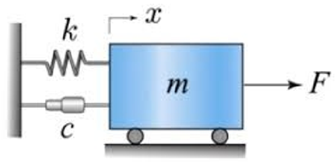

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Runge-Kutta 5</font>

Se carga un reactor con una sustancia $A$ diluida en agua. En determinadas condiciones, dicha sustancia reacciona para formar un producto deseado $B$. A su vez, el producto $B$ continúa reaccionando para formar una sustancia no deseada $$C, de acuerdo al siguiente esquema:

$$ A \xrightarrow{r_1} B \xrightarrow{r_2} C  $$

donde $r_1$ es la velocidad de la primera etapa y $r_2$ es la velocidad de la segunda etapa de reacción. Ambas velocidades dependen de las concentraciones de las sustancias y de la temperatura de trabajo, según:

$$r_1 = A_1 e^{-\frac{E_1}{RT}} c_A, \quad r_2 = A_2 e^{-\frac{E_2}{RT}} c_B,$$

donde $c_A$ y $c_B$ son las concentraciones de $A$ y $B$, $T$ es la temperatura del reactor, $A_1$ y $A_2$ son dos parámetros que valen $0.5\, min^{-1}$ y $0.3\, min^{-1}$, respectivamente, $E_1$ y $E_2$ valen $1000 \,cal/mol$ y $1500\, cal/mol$ y $R$ es la constante de los gases, cuyo valor es de $1.9872\, cal\, mol^{-1}\, K^{-1}$. En estas condiciones, las concentraciones de $A$ y $B$ varían según:

$$\frac{dc_A}{dt} = -r_1, \quad \frac{dc_B}{dt} = r_1 - r_2.$$

Al llevarse a cabo, las reacciones liberan energía en forma de calor. Considerando que el reactor está aislado del ambiente, la temperatura varía de acuerdo a:

$$\frac{dT}{dt} = \frac{1}{c_v}(r_1 ∆H_1 + r_2∆H_2),$$

donde $c_v$ es la capacidad calorífica del sistema, cuyo valor es $18\, cal\, L^{-1}\, K^{-1}$ y $∆H_1$ y $∆H_2$ son los calores de reacción, que valen $2000 cal/mol$ y $1200 cal/mol$ respectivamente.

El reactor se llena con agua a una temperatura de $298 K$ y se agrega sustancia A que se mezcla rápidamente a fin de tener una concentración inicial de $0.5 mol/L$. En base a esta información:

1. Determine, con un error menor a $10^{-6} mol/L$, las concentraciones que alcanzan $A$ y $B$ luego de media hora de reacción.

2. Al cabo de un cierto tiempo de reacción se agrega un inhibidor que detiene las reacciones. Si se desea maximizar la producción de $B$, ¿en qué momento debe agregarse dicho inhibidor?¿Cuál es la temperatura del reactor en ese momento?

3. Si la reacción continuara indefinidamente, ¿cuál es la mayor temperatura que podría alcanzar el reactor?

4. Si quisiera mejorar la producción de $B$, ¿debería utilizar agua más fría o más caliente al inicio de la reacción? Suponga que puede decidir nuevamente en qué momento agregar el inhibidor.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Runge-Kutta 6</font>


Luego del accidente sufrido en un circo chileno en julio de 2018, donde el hombre bala salió despedido del cañón con demasiada potencia cayendo muchos metros después de la red de seguridad, la Comisión Internacional del Circo decidió diseñar un nuevo traje reglamentario, con un sistema de frenado inteligente. El mismo consiste en una fuerza de resistencia proporcional a la velocidad del individuo que se activa cuando éste supera los 10 metros de altura. Más exactamente, llamando $\vec{r} = (x1, x2)$ a la posición del hombre bala en un plano vertical, la fuerza resultante que actúa sobre el sujeto es

$$
\vec{F} \left\{
  \begin{aligned} m \vec{g}, \quad &si\, x_2 <10, \\
    m \vec{g} - 20 \vec{v}, \quad &si\, x_2 \ge 10.
  \end{aligned}
\right.
$$

donde $\vec{v} = \frac{d\vec{r}}{dt(t)}$ es el vector velocidad y $\vec{g} = (0, -g)$, siendo $g = 9.8 m/s^2$ la constante de aceleración gravitacional.

1. Utilizando la segunda Ley de Newton $\vec{F} = m \vec{a}$, escriba el problema a valores iniciales correspondiente para las variables de estado $x_1(t)$ y $x_2(t)$, considerando un sujeto de masa $m$ que sale desde el origen con
velocidad inicial $\vec{v_0} = (v_0 cos θ_0, v_0 sen θ_0)$. Escriba el PVI como un sistema de primer orden.

2. Encuentre la altura máxima que alcanza el hombre bala, si consideramos que los datos son $m = 75$, $v_0 = 22$ y $θ_0 = π/3$.

3. Determine la distancia horizontal recorrida por el hombre bala desde que sale despedido del cañón hasta que toca la red de seguridad, que tiene 2 metros de altura.

4. ¿Cuánto tiempo permanece en el aire antes de hacer contacto con la red?


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

## 4.6. Cómo calcular soluciones con una precisión deseada <a name = "sec:como.calcular.soluciones" ></a>

Python tiene algoritmos automáticos adaptativos para calcular soluciones con una precisión deseada, pero no los utilizaremos en este curso.

 Para calcular una solución con cierta precisión en un instante de tiempo $t$ haremos como se describe a continuación, que es similar a lo hecho para integrales en la Sección (3.5).

 Consideremos el problema de calcular la solución del siguiente (PVI) a tiempo $t = 10$ con un error menor a $10^{-4}$:

 $$
 \begin{equation*}
 \begin{cases}
 y' = -y + t + \sin(t) + \cos(t), \quad &t \ge 0 \\
 y(0) = 2.5
 \end{cases}
 \end{equation*}
 $$



Procedemos con los siguientes pasos:

1.   Definimos la función $f$:

In [ ]:
import numpy as np
f = lambda t, y: -y + t + np.sin(t) + np.cos(t)

2.   Tomamos un valor de $L=20$ y resolvemos, por ejemplo con Euler:

In [ ]:
L=20
t,Y = euler(f,[0,10],[2.5],L)

3.    Aquí viene un punto importante. Hemos resuelto el PVI en el intervalo $[0,10]$, luego, la aproximación de la solución $y$ a tiempo $t=10$ está en la última posición del vector $\texttt{Y}$. Como resolvimos con $L$ intervalos, esta posición es la $L+1$. Para ver la aproximación escribimos `print(Y[L])` o bien `print(Y[-1])` obteniendo el siguiente resultado:

    `8.48878015`

4.    Ahora comenzamos a mejorar la precisión, duplicando $L$:

    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.47365301`

    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.46510056`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.46066162`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.45840935`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.45727587`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.45670739`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.45642273`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.45628029`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`

    `8.45620905`
 	  
    `L = 2*L; t,Y = euler(f,[0,10],[2.5],L); print(Y[-1])`
 	  
    `8.45617342`

     	. . .

5.    Todavía no queda claro si la solución será $8.4561\dots$ o $8.4560\dots$. Deberíamos seguir probando, pero ya $L=20480$. Tal vez sea momento de reconsiderar, y utilizar el método de Runge-Kutta de orden 2 ó 4, que llegará a mejor precisión con menos sub-intervalos.


## 4.7. Estabilidad de métodos numéricos <a name = "sec:estabilidad.de.métodos.numéricos" ></a>

Consideremos el siguiente PVI:

$$
\left\{
  \begin{aligned}
    y' &= -100 y, \quad t > 0, \\
    y(0) &= 1,
  \end{aligned}
\right.
$$

cuya solución exacta es $y(t) = e^{-100 t}$. Este es un problema *estable* dado que la solución tiende a cero cuando $t \to \infty$ y más aún, si tomamos soluciones con $y(0) = y_0$ y $\tilde y(0) = \tilde y_0$, entonces se cumple

$$
| y(t) - \tilde y(t) | \le e^{-100 t} |y_0 - \tilde y_0|.
$$



Es decir, la diferencia existente a tiempo $t=0$ disminuye (¡exponencialmente!) cuando $t$ crece.

Consideremos ahora su resolución con el método de Euler, con $h=0.1$. Resulta:

$
\begin{align*}
Y_1 &= 1 \\
Y_2 &= Y_1 + h f(t_1,Y_1) = Y_1 + h (-100 Y_1) = 1 + 0.1 (-100 \times 1) = 1 - 10 = -9 \\
Y_3 &= Y_2 + h f(t_2,Y_2) = Y_2 + h (-100 Y_2) = -9 + 0.1 (-100 \times (-9)) = -9 + 90 = 81 \\
Y_4 &= Y_3 + h f(t_3,Y_3) = Y_3 + h (-100 Y_3) = 81 + 0.1 (-100 \times 81) = 81 - 810 = -729 \\
Y_5 &= \dots = 6561 \\
Y_6 &= \dots = -59049 \\
&\vdots  \\
&\text{¡Nada que ver con la solución!}
\end{align*}
$

Probemos con $h$ más pequeño, por ejemplo $h = 0.05$. Resulta:

$
\begin{align*}
Y_1 &= 1 \\
Y_2 &= Y_1 + h f(t_1,Y_1) = Y_1 + h (-100 Y_1) = 1 + 0.05 (-100 \times 1) = 1 - 5 = -4 \\
Y_3 &= Y_2 + h f(t_2,Y_2) = Y_2 + h (-100 Y_2) = -4 + 0.05 (-100 \times (-4)) = -4 + 20 = 16 \\
Y_4 &= Y_3 + h f(t_3,Y_3) = Y_3 + h (-100 Y_3) = 16 + 0.05 (-100 \times 16) = 16 - 80 = -64 \\
Y_5 &= \dots = 256 \\
Y_6 &= \dots = -1024 \\
&\vdots  \\
&\text{¡Nada que ver con la solución!}
\end{align*}
$

Probemos con $h$ más pequeño, por ejemplo $h = 0.02$. Resulta:

$
\begin{align*}
Y_1 &= 1 \\
Y_2 &= Y_1 + h f(t_1,Y_1) = Y_1 + h (-100 Y_1) = 1 + 0.02 (-100 \times 1) = 1 - 2 = -1 \\
Y_3 &= Y_2 + h f(t_2,Y_2) = Y_2 + h (-100 Y_2) = -1 + 0.02 (-100 \times (-1)) = -1 + 2 = 1 \\
Y_4 &= Y_3 + h f(t_3,Y_3) = Y_3 + h (-100 Y_3) = 1 + 0.02 (-100 \times 1) = 1 - 2 = -1 \\
Y_5 &= \dots = 1 \\
Y_6 &= \dots = -1 \\
&\vdots  \\
&\text{¡Nada que ver con la solución!}
\end{align*}
$

Probemos con $h$ más pequeño, por ejemplo $h = 0.01$. Resulta:

$
\begin{align*}
Y_1 &= 1 \\
Y_2 &= Y_1 + h f(t_1,Y_1) = Y_1 + h (-100 Y_1) = 1 + 0.01 (-100 \times 1) = 1 - 1 = 0 \\
Y_3 &= Y_2 + h f(t_2,Y_2) = Y_2 + h (-100 Y_2) = 0 + 0.02 (-100 \times 0) = 0 + 0 = 0 \\
Y_4 &= Y_3 + h f(t_3,Y_3) = Y_3 + h (-100 Y_3) = 0 + 0.02 (-100 \times 0) = 0 + 0 = 0 \\
Y_5 &= \dots = 0 \\
Y_6 &= \dots = 0 \\
&\vdots  \\
&\text{Esta ya se parece un poco...}
\end{align*}
$

Para $h$ más pequeños ya se parece un poco más. Pero para $h > 0.01$ las soluciones son realmente diferentes a la solución exacta $y = e^{-100 t}$. Es más, si $h > 0.02$, $Y_n \to \infty$ cuando $n \to \infty$.

> Para los métodos explícitos que usamos en este curso, en algunas situaciones hace falta que $h$ sea muy pequeño para que el método funcione bien.
Hay casos en que $h$ debe ser demasiado pequeño, y hay que recurrir a otros métodos que no tengan este problema. Los métodos que funcionan mejor en este caso son los llamados *implícitos*.


#### Método Retro-Euler o Euler implícito


El método de Euler se puede obtener a partir de la fórmula de Taylor alrededor de $t_n$, en efecto

$$
\begin{align*}
  y(t_{n+1}) &= y(t_n) + h y'(t_n) + O(h^2) \\
  y(t_{n+1}) &\approx y(t_n) + h f(t_n,y(t_n))  \\
  Y_{n+1} &= Y_n + h f(t_n,Y_n)
\end{align*}
$$

Si usamos la fórmula de Taylor alrededor de $t_{n+1}$ obtenemos

$$
\begin{align*}
  y(t_n) &= y(t_{n+1}) - h y'(t_{n+1}) + O(h^2) \\
  y(t_{n+1}) &= y(t_n) + h y'(t_{n+1}) + O(h^2) \\
  y(t_{n+1}) &\approx y(t_n) + h f(t_{n+1},y(t_{n+1}))  \\
  Y_{n+1} &= Y_n + h f(t_{n+1},Y_{n+1})
\end{align*}
$$

El método de Euler implícito o Retro Euler se define entonces por la iteración

$$
Y_{n+1} = Y_n + h f(t_{n+1},Y_{n+1}),
$$

Es decir, $Y_{n+1}$ es la solución $Y$ de la ecuación algebraica

$$
Y= Y_n + h f(t_{n+1},Y).
$$

Este método implica resolver, en cada paso, una ecuación o sistema de ecuaciones que en general será no lineal.
En cada paso se puede resolver con un método tipo Newton (por ejemplo). Este método tiene un costo adicional de resolver un sistema no lineal en cada paso de tiempo, pero permite tomar $h$ mucho más grande que el método de Euler explícito, en especial cuando $\frac{\partial f}{\partial y} < 0$ y $\Big|\frac{\partial f}{\partial y}\Big|$ es grande (ecuaciones stiff).

## Ejercicios Adicionales ✍

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en este capítulo. Como verás, no hay un método único para resolver la mayoría de estos ejercicios.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

<font size="4">Ejercicio Adicional 1</font>

$$
\text{} \left\{
  \begin{aligned} y' &= f(t,y) = -y +\sin(t)+\cos(t) , \\
    y(0 ) &= 0.
  \end{aligned}
\right.
$$

Se desea conocer el valor de la variable de estado y a tiempo t = 2.

1. Complete la siguiente tabla con la aproximación de y(2) obtenida utilizando los métodos de Euler, RK2 y RK4 con los pasos indicados:

|h|L|Euler|RK2|RK4|
|-|-|-|-|-|
|1/10|
|1/20|
|1/40|
|1/80|
|1/160|
|1/320|

*Sugerencia: para armar una tabla a partir de vectores, explore la función ```DataFrame``` de la librería ```pandas```.*

2. Determine la cantidad de pasos $L$ y el número de evaluaciones de $f$ que fueron necesarios, en cada método, para obtener $y(2)$ con:

$\quad \quad$ $(i)$ Tres decimales correctos. $\quad$ $(ii)$ Seis decimales correctos. $\quad$ $(iii)$ Diez decimales correctos.




In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 2</font>

(Modelo predador-presa de Lotka-Volterra) Consideremos el siguiente modelo

$$
\text{} \left\{
  \begin{aligned} x'_1(t) &= x_1(3-0.002 x_2), \\
    x'_2(t) &= -x_2(0.5-0.0006x_1).
  \end{aligned}
\right.
$$

1. ¿Cuál variable representa al predador y cuál a la presa? Para determinar esto, tenga en cuenta las siguientes
preguntas:

$\quad$ ¿Cuál de las dos especies puede sobrevivir sin la existencia de la otra?

$\quad$ ¿Qué especie se extingue si la otra no existe?

2. Graficar la evolución de ambas poblaciones considerando que la población inicial de presas es 1600 y la de predadores es 800, y teniendo en cuenta que el tiempo $t$ se mide en meses. Describir el fenómeno representado. *Sugerencia: Utilice un método que usted considere apropiado, y un intervalo de tiempo que sea representativo de lo que sucede.*

3. Determine la duración del ciclo o período en este modelo. Explique brevemente óomo lo hizo.

4. Determine el primer momento en que ambas poblaciones coinciden. Identificar la tasa de crecimiento instantánea, explicando si ambas poblaciones crecen, ambas decrecen, o si una crece y la otra decrece.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 3</font>

(Péndulo simple) Si consideramos un péndulo de brazo rígido de longitud  $L$, donde no hay friccóon ni resistencia del aire, el ángulo $\phi(t)$ que forma el péndulo con la vertical satisface la siguiente ecuación diferencial de orden dos:

$$\phi''(t) + \frac{g}{L} \sin \phi(t) = 0,$$

donde $g = 9.81 g/m^2$ es la constante de aceleración gravitacional.

Supongamos (por simplicidad) que la longitud del brazo es igual a 9.81 m, con lo que obtenemos la ecuación.

$$\phi''(t) + \sin \phi(t) = 0,$$





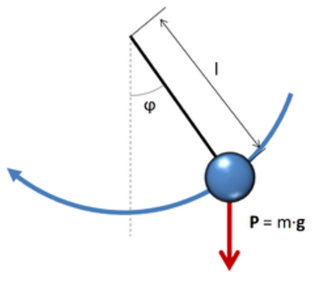

Resolver esta ecuación numéricamente en el intervalo $[0, 20]$ y explicar, en cada uno de los siguientes casos, la situación física descripta (condiciones iniciales y evolución):

1. $\phi(0) = 0.1, \phi'(0) = 0 $

2. $\phi(0) = 0.7, \phi'(0) = 0 $

3. $\phi(0) = 3.0, \phi'(0) = 0 $

4. $\phi(0) = 3.5, \phi'(0) = 0 $

5. $\phi(0) = 0, \phi'(0) = 1 $

6. $\phi(0) = 0, \phi'(0) = 1.99 $

7. $\phi(0) = 0, \phi'(0) = 2 $

8. $\phi(0) = 0, \phi'(0) = 2.01 $

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 4</font>

Un péndulo de Foucault es un péndulo esférico que puede oscilar libremente en cualquier plano vertical. Este fue utilizado por su inventor, Léon Foucault, para demostrar la rotación de la Tierra.

El movimiento de un péndulo de Foucault sin fricción se describe mediante el siguiente sistema de dos ecuaciones

$$x'' - 2 ω sen(Ψ) y' + \frac{g}{L} x = 0,\quad y'' + 2ω cos(Ψ)x' + \frac{g}{L}y = 0,\quad t ≥ 0,$$

donde $x(t)$ e $y(t)$ representan las coordenadas en el plano de la punta
del péndulo a tiempo $t$, $Ψ$ es la latitud del lugar donde se localiza el
péndulo, $ω$ y $g$ son la velocidad angular y la gravedad del planeta,
respectivamente, y $L$ es la longitud del péndulo.

Fijemos los parámetros $Ψ = π/4$, $ω = 6 \times 10^{-2} s^{-1}$, $g = 9.81 m/s^2$ y $L = 100 m$. Supongamos que soltamos el péndulo en la posición $x(0) = 0$, $y(0) = 0$, a una velocidad inicial $x'(0) = 0.3$, $y'(0) = 0.3$.

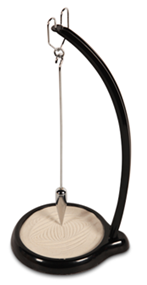

1. Obtenga una aproximación de la posición del péndulo a tiempo $t = 70$ con un error absoluto menor a $10^{-8}$.

2. ¿Cuántas veces vuelve a pasar por la posición inicial (aproximadamente) en el período de tiempo $0 < t ≤ 70$? También se desea saber en qué instantes aproximados esto ocurre (puede hacerlo a partir de un gráfico).

3. Obsérvese que el péndulo describe un gráfico similar a un flor ¿Cuántos pétalos tiene la misma para $t ∈ [0, 70]$?

4. ¿Cuál es la distancia máxima que se aleja el péndulo de la posición inicial y en qué tiempo esto ocurre?

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

<font size="4">Ejercicio Adicional 5</font>

En un tanque agitado se encuentra almacenada una sustancia $B$ diluida en agua. Dado que esta sustancia es un contaminante, se decide eliminarla por reacción química a fin de tener un compuesto menos nocivo. Para ello, se adiciona una sustancia $A$ que, en contacto con el agua, se degrada lentamente formando un
compuesto muy reactivo $R$ que reacciona rápidamente con $B$ para formar $RB$. Sin embargo, parte de $R$ se pierde puesto que también reacciona con $A$ para formar $RA$. Las reacciones químicas se muestran a continuación:

$$ A \xrightarrow{r_1} R$$
$$ R + B \xrightarrow{r_2} RB$$
$$ R + A \xrightarrow{r_3} RA$$

Las expresiones de velocidad de cada reacción (en $mol\,L^{-1} min^{-1}$) son:

$$r_1 = 0.013 c_A,\quad r_2 = 2500 c_B c_R, \quad r_3 = 1000 c_A c_R,$$

donde $c_A$, $c_B$ y $c_R$ son las concentraciones de $A$, $B$ y $R$ respectivamente, y su unidad es $mol/L$. A través de un balance de masa, puede describirse la variación temporal de cada una de ellas:

$$ \frac{dc_A}{dt} = -r_1 - r_3, \quad \frac{dc_B}{dt} = -r_2, \quad \frac{dc_R}{dt} = r_1 - r_2 - r_3.$$

Inicialmente, la concentración de $B$ es de $1 mol/L$ y se añade $A$ a fin de tener una concentración inicial igual a la de $B$.

1. Grafique la evolución temporal de las concentraciones durante los primeros 50 minutos. *Sugerencia: resolver numéricamente el PVI utilizando una cantidad de pasos $L$ con la cual las soluciones obtenidas sean representativas del problema en cuestión.*

2. Determine las concentraciones de $A$ y $B$ al cabo de 50 minutos. Calcule el porcentaje de $B$ que logró eliminarse y el porcentaje de $A$ se consumió en el proceso.

3. ¿Qué porcentaje de $B$ lograría eliminarse si la reacción continuara indefinidamente?

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

## Bibliografía
Si le interesa leer un poco más sobre los temas de este capítulo, le recomendamos los siguientes libros:

*   K.E. Atkinson,
  *An introduction to Numerical Analysis*, 2nd edition, John
  Wiley \& Sons, 1989.
*   Charles Van Loan, *Introduction to scientific computing. A matrix-vector approach using Octave*, Prentice Hall, 1997.




